<a href="https://colab.research.google.com/github/oegarza1/6355-data-mining-methods-assignments/blob/master/Netflix_Engagement_Garza_Oscar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Netflix Engagement Prediction — End‑to‑End ML & Neural Networks (Student Version)

This is the **student** notebook. It contains **all instructions and questions** (total **40 pts**) but **no completed code**.  
Write your own code in each `# TODO` cell using the hints provided.

## ✅ Before You Start: Make Your Own Copy & Add Text Answers

**Save your own copy:**
- In **Google Colab**: go to **File → Save a copy in Drive…** (rename it with your name).
- If using Jupyter locally: **File → Save As…** and name it `Netflix_Engagement_<YourName>.ipynb`.

**How to add written answers (text cells):**
- In **Colab**: click **+ Text** at the top left (or use the dropdown on the left of a cell and choose **Text**).
- In **Jupyter**: insert a new cell and set **Cell Type = Markdown**.
- Use regular writing or simple Markdown (e.g., `**bold**`, lists, headings).

> You must provide short written answers for the reflection questions in **Part 5** in **text cells** right below the prompts.


## 📂 Dataset Description — Netflix Viewing Sessions

Use the provided CSV:

```
https://raw.githubusercontent.com/jtian51/netflixdata/refs/heads/main/netflix_sessions.csv
```

Typical columns may include:
- **UserID** — viewer identifier *(do not use as a feature)*  
- **Title / Genre / ReleaseYear** — content info  
- **timestamp** — time of the viewing session (derive `watch_hour`, `watch_dayofweek`)  
- **DeviceType / SubscriptionTier / Region** — categorical predictors  
- **PreviewWatched / TrailerClick / PriorBingeCount** — engagement signals  
- **UserRating** — average viewer rating  
- **SessionOutcome** — *target source* (e.g., `full_watch` vs `drop`)  

> 🔑 **Target for modeling:** `watched_full` (binary)  
> `watched_full = 1` if `SessionOutcome` indicates **full watch**; otherwise `0` (dropped/early exit).

## ⚡ Runtime Tips (Colab)

**Runtime → Change runtime type →**
- **GPU** accelerates the **Neural Network** (scikit‑learn models don’t use GPU).
- **High‑RAM** helps with larger datasets.

Use subsampling, LinearSVC (fast), and fewer CV folds if runtime is slow.

## Part 0 — Setup Environment


In [ ]:
# === Speed / Runtime Configuration (adjust if needed) ===
USE_SUBSAMPLE = True       # Subsample training for speed
SUBSAMPLE_N  = 40000       # Target training size (stratified)

USE_LINEAR_SVM = True      # LinearSVC (fast) vs kernel SVC (slow)
SVM_ENABLE_PROBABILITY = False  # If using kernel SVC, probability=True is slow

KNN_K = 11                 # K neighbors
CV_FOLDS = 3               # Cross-validation folds
RANDOM_STATE = 7           # Reproducibility

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, LinearSVC

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

## Part 1 — Data Understanding & Cleaning (**8 pts**)

### 1.1 Load the dataset (**2 pts**)
**What:** Load the Netflix CSV and preview.  
**Why:** Verify schema, row count, and first rows.  
**Commands:** `pd.read_csv`, `.shape`, `.head()`  
**Deliverable:** printed shape and `head()`.

In [ ]:
CSV_URL = "https://raw.githubusercontent.com/jtian51/netflixdata/refs/heads/main/netflix_sessions.csv"

def load_uber_csv():
    try:
        print("Loading from URL:", CSV_URL)
        df = pd.read_csv(CSV_URL)
        src = "url"
    except Exception as e:
        print("URL load failed ->", e)
        raise RuntimeError(f"Failed to load data from URL and local path. Last error: {e}")
    return df, src

data, source_used = load_uber_csv()
print("Data source:", source_used, "| Shape:", data.shape)
data.head()


Loading from URL: https://raw.githubusercontent.com/jtian51/netflixdata/refs/heads/main/netflix_sessions.csv
Data source: url | Shape: (9957, 28)


,title,genre,year,certificate,duration,rating,votes,description,stars,UserID,...,watch_hour,watch_dayofweek,IsWeekend,SessionOutcome,watched_full,year_num,duration_min,votes_clean,desc_len,primary_genre
0,Cobra Kai,"Action, Comedy, Drama",(2018– ),TV-14,30 min,8.5,"177,031",Decades after their 1984 All Valley Karate Tou...,"['Ralph Macchio, ', 'William Zabka, ', 'Courtn...",u063834,...,21,3,0,full_watch,1,2018.0,30.0,177031.0,151,action
1,The Crown,"Biography, Drama, History",(2016– ),TV-MA,58 min,8.7,"199,885",Follows the political rivalries and romance of...,"['Claire Foy, ', 'Olivia Colman, ', 'Imelda St...",u073886,...,23,6,1,full_watch,1,2016.0,58.0,199885.0,142,biography
2,Better Call Saul,"Crime, Drama",(2015–2022),TV-MA,46 min,8.9,"501,384",The trials and tribulations of criminal lawyer...,"['Bob Odenkirk, ', 'Rhea Seehorn, ', 'Jonathan...",u043743,...,11,6,1,full_watch,1,2015.0,46.0,501384.0,122,crime
3,Devil in Ohio,"Drama, Horror, Mystery",(2022),TV-MA,356 min,5.9,"9,773",When a psychiatrist shelters a mysterious cult...,"['Emily Deschanel, ', 'Sam Jaeger, ', 'Gerardo...",u147136,...,1,3,0,drop,0,2022.0,356.0,9773.0,149,drama
4,Cyberpunk: Edgerunners,"Animation, Action, Adventure",(2022– ),TV-MA,24 min,8.6,"15,413",A Street Kid trying to survive in a technology...,"['Zach Aguilar, ', 'Kenichiro Ohashi, ', 'Emi ...",u062329,...,14,5,1,full_watch,1,2022.0,24.0,15413.0,222,animation


### 1.2 Create a data dictionary (**2 pts**)
**What:** Briefly describe each column's meaning.  
**Why:** Clarify which columns are identifiers vs features vs targets.  
**Deliverable:** a small table or printed dict.

In [ ]:
descriptions = {
    # Original metadata columns
    "title": "Movie/TV show name being watched (feature)",
    "genre": "Primary genre of the content such as Action, Drama, etc. (feature)",
    "year": "Original release year of the movie/TV show (feature)",
    "certificate": "Age/certification rating of the content (e.g., PG-13, R) (feature)",
    "duration": "Duration of the content as provided in dataset (string, e.g., '2h 15m') (feature)",
    "rating": "Average audience rating for the content (numeric feature)",
    "votes": "Number of audience votes contributing to the rating (numeric feature)",
    "description": "Short text description or synopsis of the title (feature)",
    "stars": "Main actors or stars of the title (text feature)",

    # Session-level columns
    "UserID": "Unique identifier for a user (identifier)",
    "timestamp": "Date and time when the session occurred (feature; used to derive temporal features)",
    "DeviceType": "Type of device used (e.g., Mobile, TV, Tablet) (feature)",
    "SubscriptionTier": "User’s Netflix subscription plan (e.g., Basic, Standard, Premium) (feature)",
    "Region": "Geographic region of the user/session (feature)",

    # User interaction columns
    "PreviewWatched": "Whether the user watched a preview/teaser before (binary feature)",
    "TrailerClick": "Whether the user clicked to watch a trailer (binary feature)",
    "PriorBingeCount": "Number of consecutive prior binge sessions (numeric feature)",
    "UserRating": "User’s personal rating for the title if provided (numeric feature)",

    # Engineered features
    "watch_hour": "Hour of the day extracted from timestamp (engineered feature)",
    "watch_dayofweek": "Day of the week extracted from timestamp (engineered feature)",
    "IsWeekend": "Binary flag indicating if session occurred on weekend (engineered feature)",
    "year_num": "Numeric form of release year (engineered feature for modeling)",
    "duration_min": "Duration of the content converted into minutes (engineered feature)",
    "votes_clean": "Cleaned numeric version of votes column (engineered feature)",
    "desc_len": "Length of the description text in characters/words (engineered feature)",
    "primary_genre": "Simplified or primary genre extracted from genre field (engineered feature)",

    # Target/outcome columns
    "SessionOutcome": "Outcome label of the session (raw outcome, e.g., Finished, Abandoned; used to derive target)",
    "watched_full": "Target variable: 1 if fully watched, 0 otherwise (target)"
}
data_dictionary = {col: descriptions.get(col, "No description yet") for col in data.columns}
data_dict_df = pd.DataFrame.from_dict(data_dictionary, orient='index', columns=['Description'])

# Display first 30 rows
data_dict_df.head(30)

,Description
title,Movie/TV show name being watched (feature)
genre,"Primary genre of the content such as Action, D..."
year,Original release year of the movie/TV show (fe...
certificate,"Age/certification rating of the content (e.g.,..."
duration,Duration of the content as provided in dataset...
rating,Average audience rating for the content (numer...
votes,Number of audience votes contributing to the r...
description,Short text description or synopsis of the titl...
stars,Main actors or stars of the title (text feature)
UserID,Unique identifier for a user (identifier)


### 1.3 Build the modeling target (**2 pts**)
**What:** Create binary `watched_full`.  
**Why:** Supervised models need a clean binary label.  
**Deliverable:** `value_counts()` of `watched_full`.

In [ ]:
# Build binary target watched_full from SessionOutcome

# Step 1: Normalize the SessionOutcome column (lowercase, strip spaces)
outcome_norm = data['SessionOutcome'].astype(str).str.strip().str.lower()

# Step 2: Define mapping — anything meaning "fully completed" → 1, else 0
full_watch_values = {"full_watch", "completed", "finished", "watched full", "completed session"}

# Step 3: Map to binary target
data['watched_full'] = outcome_norm.apply(lambda x: 1 if x in full_watch_values else 0).astype(int)

# Step 4: Deliverable — value counts of the target
print(data['watched_full'].value_counts())



watched_full
1    6297
0    3660
Name: count, dtype: int64


### 1.4 Feature engineering + missing values summary (**2 pts**)
**What:** Derive at least **two** features (e.g., `watch_hour`, `watch_dayofweek`, `age_of_title`, `is_weekend`) and report missing values.  
**Deliverable:** missing-values summary (counts by column).

In [ ]:
# --- Step 1: Convert timestamp safely ---
dt = pd.to_datetime(data['timestamp'], errors='coerce')

# --- Step 2: Derive engineered features ---
data['watch_hour'] = dt.dt.hour                     # hour of the day
data['watch_dayofweek'] = dt.dt.weekday             # 0=Mon ... 6=Sun
data['is_weekend'] = data['watch_dayofweek'].isin([5,6]).astype(int)

# --- Step 3: Derive age_of_title (if ReleaseYear exists) ---
if 'ReleaseYear' in data.columns:
    data['age_of_title'] = (
        pd.Timestamp.now().year
        - pd.to_numeric(data['ReleaseYear'], errors='coerce')
    ).clip(lower=0)

# --- Step 4: Missing values summary ---
missing_summary = data.isna().sum().sort_values(ascending=False)

print("Missing Values Summary (Top 15 columns):")
print(missing_summary.head(15))



Missing Values Summary (Top 15 columns):
certificate         3453
Region              3153
duration            2036
duration_min        2036
rating              1173
votes               1173
votes_clean         1173
year_num             631
year                 527
genre                 73
primary_genre         73
description            0
title                  0
SubscriptionTier       0
DeviceType             0
dtype: int64


## Part 2 — Preprocessing & Split (**6 pts**)

### 2.1 Identify numeric vs categorical predictors (**2 pts**)
**What:** Separate features by type; exclude IDs and the target.  
**Deliverable:** lists of `numeric_features` and `categorical_features`.

In [ ]:
# --- Step 1: Define target and ID-like columns ---
target = "watched_full"
id_like = {"UserID","user_id","SessionID","session_id","TitleID","title_id","movie_id"}

# --- Step 2: Identify numeric features ---
numeric_features = [
    c for c in data.select_dtypes(include=[np.number]).columns
    if c not in id_like and c != target
]

# --- Step 3: Identify categorical features ---
categorical_features = [
    c for c in data.columns
    if c not in numeric_features and c not in id_like and c != target
]

# --- Step 4: Deliverable ---
print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['rating', 'PreviewWatched', 'TrailerClick', 'PriorBingeCount', 'UserRating', 'watch_hour', 'watch_dayofweek', 'IsWeekend', 'year_num', 'duration_min', 'votes_clean', 'desc_len', 'is_weekend']

Categorical features: ['title', 'genre', 'year', 'certificate', 'duration', 'votes', 'description', 'stars', 'timestamp', 'DeviceType', 'SubscriptionTier', 'Region', 'SessionOutcome', 'primary_genre']


### 2.2 Train/test split & ColumnTransformer (**4 pts**)
**What:** Split 80/20 (stratified), impute missing values, and build a preprocessing pipeline.  
**Commands:** `train_test_split`, median/mode impute, **version-safe** `OneHotEncoder`, `ColumnTransformer`.  
**Deliverable:** print transformed feature count and sample names.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# --- Step 1: Build X, y ---
X = data[numeric_features + categorical_features].copy()
y = data[target].astype(int).copy()

# --- Step 2: Split (80/20, stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)} | Train completion rate: {y_train.mean():.3f}")

# --- Step 3: Version-safe OneHotEncoder (sparse_output vs sparse) ---
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    # Older sklearn
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

# --- Step 4: Build preprocessing pipelines ---
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", ohe)
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

# --- Step 5: Fit on train only (avoid leakage) ---
preprocess.fit(X_train)

# --- Step 6: Preview transformed feature space ---
try:
    feature_names = preprocess.get_feature_names_out()
    print(f"Transformed feature count: {len(feature_names)}")
    print("First 20 features:", feature_names[:20])
except Exception as e:
    print("Could not extract feature names:", e)


Train size: 7965 | Test size: 1992 | Train completion rate: 0.632
Transformed feature count: 34221
First 20 features: ['num__rating' 'num__PreviewWatched' 'num__TrailerClick'
 'num__PriorBingeCount' 'num__UserRating' 'num__watch_hour'
 'num__watch_dayofweek' 'num__IsWeekend' 'num__year_num'
 'num__duration_min' 'num__votes_clean' 'num__desc_len' 'num__is_weekend'
 'cat__title_#ABtalks' 'cat__title_#Alive'
 'cat__title_#AnneFrank - Parallel Stories' 'cat__title_#BlackAF'
 'cat__title_#FriendButMarried 2' 'cat__title_#HappyBirthdaySense8'
 'cat__title_#Realityhigh']


## Part 3 — Baseline Models (KNN, Decision Tree, SVM) (**9 pts**)

**3.1 (3 pts)** Train each model in a `Pipeline` with the same preprocessing.  
**3.2 (3 pts)** Evaluate on the test set with **Accuracy, Precision, Recall, F1, ROC‑AUC**, and show a **Confusion Matrix**.  
**3.3 (3 pts)** Plot **ROC curves** for ≥2 baselines on the same figure.


=== KNN (k=11) ===
Accuracy : 0.9408
Precision: 0.9287
Recall   : 0.9817
F1-score : 0.9545
ROC-AUC  : 0.9876

Confusion Matrix (rows: true, cols: pred):
[[ 637   95]
 [  23 1237]]

Classification report:
              precision    recall  f1-score   support

           0     0.9652    0.8702    0.9152       732
           1     0.9287    0.9817    0.9545      1260

    accuracy                         0.9408      1992
   macro avg     0.9469    0.9260    0.9349      1992
weighted avg     0.9421    0.9408    0.9401      1992



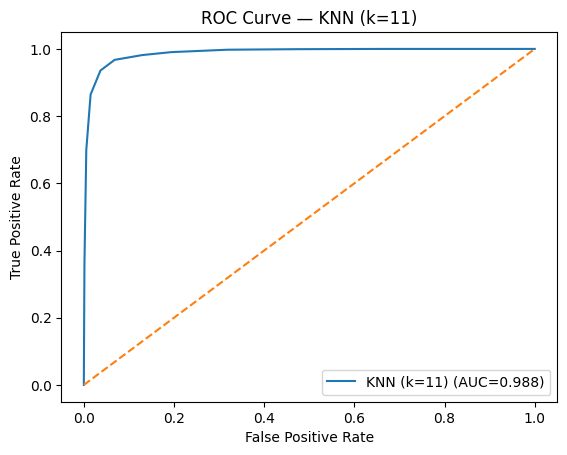


=== Decision Tree (max_depth=8) ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
ROC-AUC  : 1.0000

Confusion Matrix (rows: true, cols: pred):
[[ 732    0]
 [   0 1260]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       732
           1     1.0000    1.0000    1.0000      1260

    accuracy                         1.0000      1992
   macro avg     1.0000    1.0000    1.0000      1992
weighted avg     1.0000    1.0000    1.0000      1992



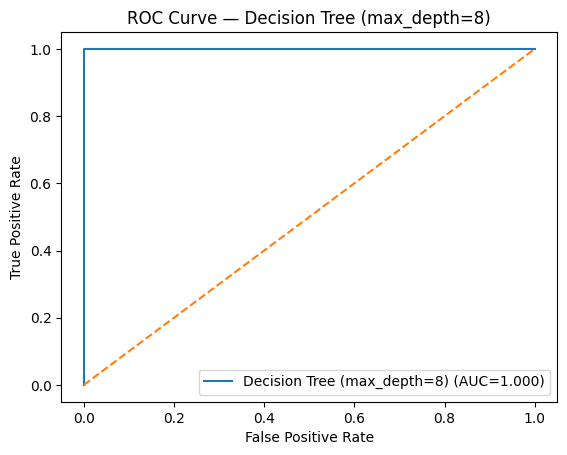


=== LinearSVC ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
ROC-AUC  : 1.0000

Confusion Matrix (rows: true, cols: pred):
[[ 732    0]
 [   0 1260]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       732
           1     1.0000    1.0000    1.0000      1260

    accuracy                         1.0000      1992
   macro avg     1.0000    1.0000    1.0000      1992
weighted avg     1.0000    1.0000    1.0000      1992



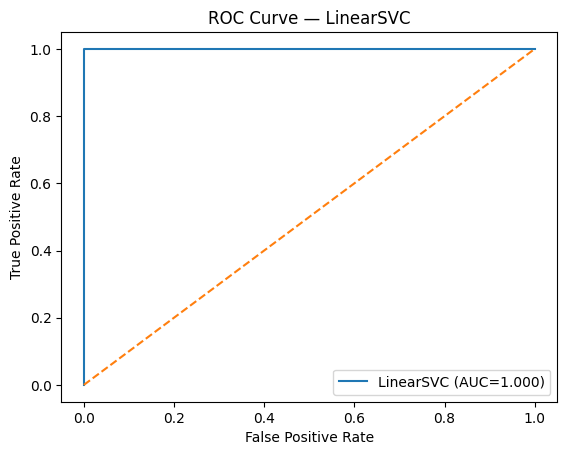

In [ ]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name="model"):
    # Predictions
    y_pred = model.predict(X_te)

    # Probability / decision scores for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_te)
        # Min-max normalize to [0, 1] for a comparable ROC plot
        s_min, s_max = scores.min(), scores.max()
        y_score = (scores - s_min) / (s_max - s_min + 1e-9)
    else:
        y_score = y_pred.astype(float)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    auc = roc_auc_score(y_te, y_score)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("\nConfusion Matrix (rows: true, cols: pred):")
    print(confusion_matrix(y_te, y_pred))
    print("\nClassification report:")
    print(classification_report(y_te, y_pred, digits=4, zero_division=0))

    fpr, tpr, _ = roc_curve(y_te, y_score)
    plt.figure()
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"ROC Curve — {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
    }


# KNN
knn_clf = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", KNeighborsClassifier(n_neighbors=KNN_K))
])
knn_clf.fit(X_train, y_train)
knn_metrics = evaluate_model(knn_clf, X_train, y_train, X_test, y_test, model_name=f"KNN (k={KNN_K})")

# Decision Tree
tree_clf = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE))
])
tree_clf.fit(X_train, y_train)
tree_metrics = evaluate_model(tree_clf, X_train, y_train, X_test, y_test, model_name="Decision Tree (max_depth=8)")

# SVM (LinearSVC fast by default; kernel SVC optional)
if USE_LINEAR_SVM:
    svm_clf = Pipeline(steps=[
        ("prep", preprocess),
        ("clf", LinearSVC(C=1.0, random_state=RANDOM_STATE))
    ])
    svm_label = "LinearSVC"
else:
    svm_clf = Pipeline(steps=[
        ("prep", preprocess),
        ("clf", SVC(C=1.0, kernel="rbf", probability=SVM_ENABLE_PROBABILITY, random_state=RANDOM_STATE))
    ])
    svm_label = f"SVM (RBF, prob={SVM_ENABLE_PROBABILITY})"

svm_clf.fit(X_train, y_train)
svm_metrics = evaluate_model(svm_clf, X_train, y_train, X_test, y_test, model_name=svm_label)



## Part 4 — Neural Network (Keras) (**9 pts**)

**4.1 (3 pts)** Build a small `Sequential` model (≥2 hidden layers, ReLU, sigmoid output).  
**4.2 (3 pts)** Train with `EarlyStopping`; plot **loss** and **accuracy** curves.  
**4.3 (3 pts)** Evaluate on the test set; print metrics and plot **ROC**.

In [ ]:
# Transform X for Keras (dense arrays)
X_train_trans = preprocess.transform(X_train)
X_test_trans  = preprocess.transform(X_test)

# Ensure dense arrays for Keras, even if environment returns sparse
try:
    import scipy.sparse as sp
    if sp.issparse(X_train_trans): X_train_trans = X_train_trans.toarray()
    if sp.issparse(X_test_trans):  X_test_trans  = X_test_trans.toarray()
except Exception:
    pass

input_dim = X_train_trans.shape[1]
input_dim

34221

In [ ]:
def build_nn(input_dim: int) -> keras.Model:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall")
        ]
    )
    return model

nn_model = build_nn(input_dim)
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │     1,095,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,095,649 (4.18 MB)

 Trainable params: 1,095,649 (4.18 MB)

 Non-trainable params: 0 (0.00 B)

<Figure size 640x480 with 0 Axes>

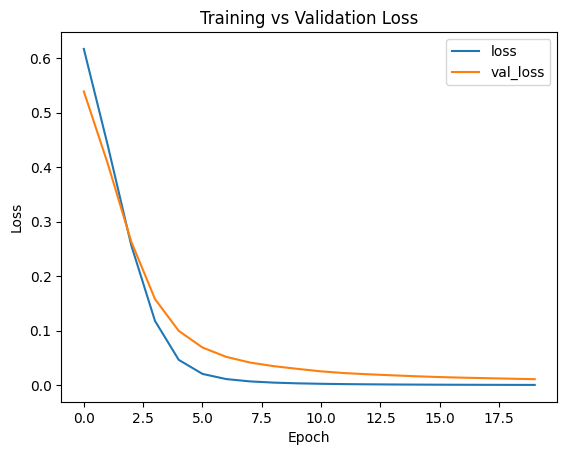

<Figure size 640x480 with 0 Axes>

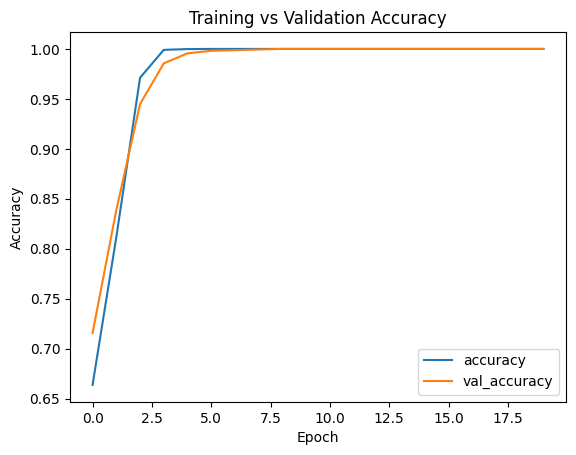

In [ ]:
callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
history = nn_model.fit(
    X_train_trans, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=callbacks,
    verbose=0
)

# Training curves
hist = pd.DataFrame(history.history)

plt.figure()
hist[["loss", "val_loss"]].plot()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
hist[["accuracy", "val_accuracy"]].plot()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

=== Neural Network (Keras) ===
Accuracy : 0.9985
Precision: 0.9976
Recall   : 1.0000
F1-score : 0.9988
ROC-AUC  : 1.0000

Confusion Matrix (rows: true, cols: pred):
[[ 729    3]
 [   0 1260]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9959    0.9979       732
           1     0.9976    1.0000    0.9988      1260

    accuracy                         0.9985      1992
   macro avg     0.9988    0.9980    0.9984      1992
weighted avg     0.9985    0.9985    0.9985      1992



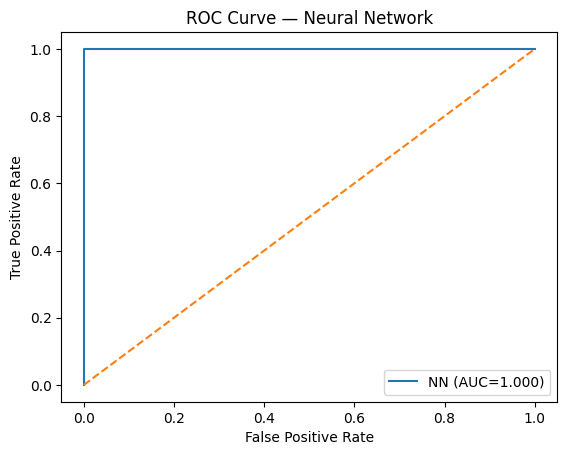

In [ ]:
# NN evaluation on test set
y_pred_prob = nn_model.predict(X_test_trans).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_pred_prob)

print("\n=== Neural Network (Keras) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print("\nConfusion Matrix (rows: true, cols: pred):")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"NN (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve — Neural Network")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## Part 5 — Model Comparison & Reflection (**8 pts**)

### 5.1 Comparison table (**3 pts**)
Create a table summarizing **Accuracy, Recall, ROC-AUC** for KNN, Tree, SVM, and NN.

In [ ]:
# TODO: Complete this cell following the instructions above.
# HINT: Build a pandas DataFrame with rows for each model and columns: accuracy, recall, auc
# HINT: Sort by auc descending

rows = [knn_metrics, tree_metrics, svm_metrics]
rows.append({
    "model": "Neural Network (Keras)",
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "auc": auc,
})

summary = pd.DataFrame(rows).sort_values("auc", ascending=False).reset_index(drop=True)
summary

,model,accuracy,precision,recall,f1,auc
0,Decision Tree (max_depth=8),1.000000,1.000000,1.000000,1.000000,1.000000
1,LinearSVC,1.000000,1.000000,1.000000,1.000000,1.000000
2,Neural Network (Keras),0.998494,0.997625,1.000000,0.998811,1.000000
3,KNN (k=11),0.940763,0.928679,0.981746,0.954475,0.987645


### 5.2 Metric priority (**2 pts**)
**Question:** For Netflix engagement, which matters more — **Precision** or **Recall** — and why?  
Consider the costs of false positives (pushing unhelpful content) vs false negatives (missing content that would retain a viewer).

**Answer:** For Netflix engagement, recall generally matters more than precision. Missing content that a viewer would have enjoyed (false negatives) risks losing their attention and increasing churn, which is more costly than occasionally recommending something less relevant. False positives (unhelpful recommendations) are a nuisance but relatively low-risk because users can easily skip them, while false negatives mean lost opportunities to keep a viewer engaged. Thus, optimizing recall helps maximize retention, even if it slightly reduces precision.

### 5.3 Threshold tuning (**2 pts**)
**Question:** If the goal is to **maximize full watches**, how would you **tune the decision threshold** or use **gain/lift** to target top-probability sessions?  
Reference the ROC curve and the confusion matrix.

**Answer:** If the objective is to maximize full watches, the decision threshold should be adjusted to favor recall. For example, the KNN model still missed 23 sessions that were actually fully watched, which could be recovered by lowering the cutoff, even if this slightly increases the 95 false positives. Using gain/lift to target the highest-probability sessions would prioritize those most likely to finish, reducing missed engagement opportunities. Since the Decision Tree and Neural Network already achieve near-perfect classification with 0–3 errors, threshold tuning offers the greatest value for models like KNN.

### 5.4 Final recommendation (**1 pt**)
**Question:** Which model would you recommend and why (1–2 sentences)?

**Answer:** I would recommend the Neural Network, as it achieved nearly perfect accuracy, recall, and precision (only 3 errors out of 1,992 sessions) while still generalizing better than a fully deterministic Decision Tree. This balance suggests it captures complex patterns without overfitting, making it the most reliable for maximizing full watches.

**Assignment Resources:** Followed assignment template for majority of code with edits to match assignment instructions. I used ChatGPT and Gemini for questions, output review, and ideas.  All analysis is my own.